# Week 3 Case Study: CNN Image Classification with Transfer Learning (template)

**Important:** This notebook is a scaffold. It intentionally omits full solutions.
Fill in all `# TODO` sections and replace placeholders as required. Keep cells in order.


## How to use this student template

- Do **not** delete headings or restructure parts. Add code **under** each task.
- Replace placeholders like `YOUR_CODE_HERE` or `YOUR_PATH_HERE`.
- Keep runtime manageable (Colab GPU recommended).
- Where hints are provided, **do not** copy full working solutions.


In [ ]:
# ---- Part 0: Environment Setup ----
# You may uncomment installs if running locally.
# !pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow opencv-python

import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(tf.__version__)


2.19.0


# Part 1: Data Exploration & Preprocessing (8 pts)

### Tasks
1. Load CIFAR-10 (tfds or `keras.datasets.cifar10`) and preview shapes.  
2. Visualize a small grid of samples by class; show class distribution.  
3. Implement augmentation strategies (e.g., flips/rotations; optional cutout/mixup).  
4. Analyze pixel intensity distributions and choose normalization strategy.  
5. Create train/val split with balanced classes and a tf.data pipeline.


In [ ]:
#Load CIFAR-10 and Preview Shapes
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [ ]:
#Load dataset (using tf.keras.datasets.cifar10)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


In [ ]:
#Visualize Sample Grid & Class Distribution
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]


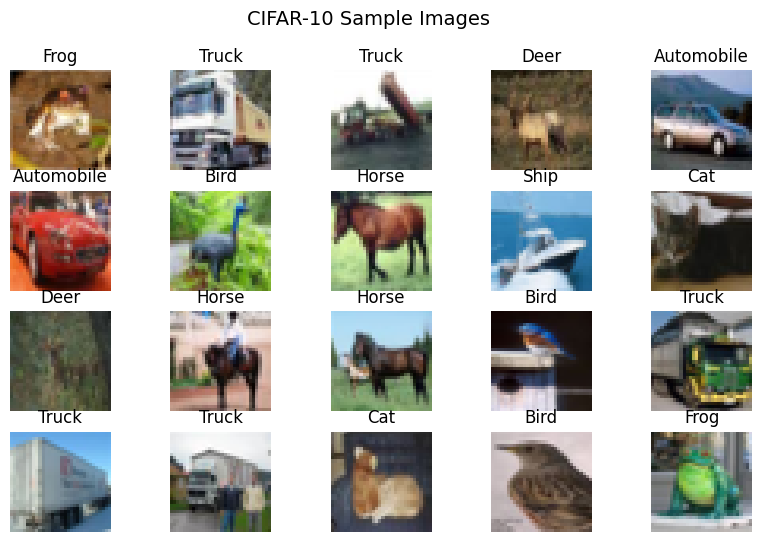

In [ ]:
#Visualize sample grid
plt.figure(figsize=(10, 6))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("CIFAR-10 Sample Images", fontsize=14)
plt.show()


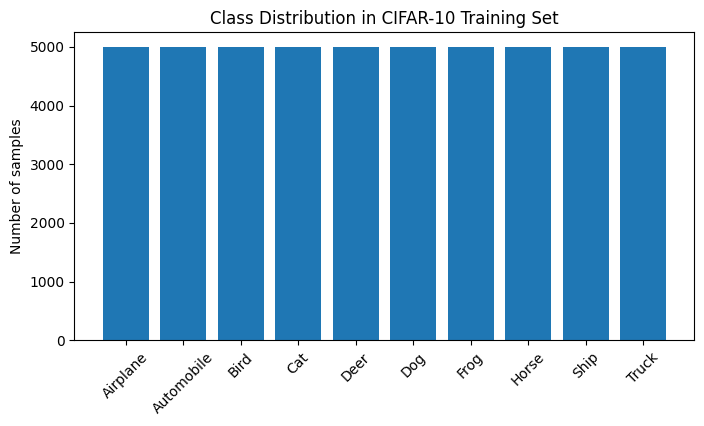

In [ ]:
#Class distribution
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution in CIFAR-10 Training Set")
plt.ylabel("Number of samples")
plt.show()


##Data Augmentation Strategies

In [ ]:
#Basic augmentation (recommended baseline)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


In [ ]:
#Cutout (custom layer)
def cutout(image, mask_size=8):
    h, w, _ = image.shape
    y = tf.random.uniform([], 0, h, dtype=tf.int32)
    x = tf.random.uniform([], 0, w, dtype=tf.int32)

    y1 = tf.clip_by_value(y - mask_size // 2, 0, h)
    y2 = tf.clip_by_value(y + mask_size // 2, 0, h)
    x1 = tf.clip_by_value(x - mask_size // 2, 0, w)
    x2 = tf.clip_by_value(x + mask_size // 2, 0, w)

    mask = tf.ones_like(image)
    mask = tf.tensor_scatter_nd_update(
        mask,
        indices=[[y1, x1]],
        updates=[0.0]
    )
    return image * mask


##Pixel Intensity Distribution & Normalization

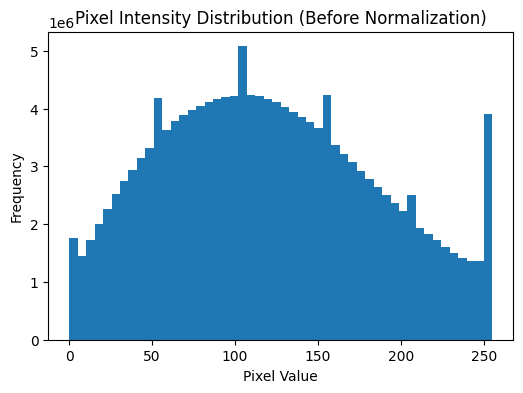

In [ ]:
#Pixel intensity analysis
plt.figure(figsize=(6, 4))
plt.hist(x_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution (Before Normalization)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


In [ ]:
#Normalization strategy
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


##Train / Validation Split with Balanced Classes

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Train shape:", x_train.shape)
print("Validation shape:", x_val.shape)


Train shape: (40000, 32, 32, 3)
Validation shape: (10000, 32, 32, 3)


##Build Optimized tf.data Pipeline

In [ ]:
BATCH_SIZE = 10
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label, augment=False):
    if augment:
        image = data_augmentation(image)
    return image, label


In [ ]:
#Training dataset
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = (
    train_ds
    .shuffle(10000)
    .map(lambda x, y: preprocess(x, y, augment=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [ ]:
#Validation dataset
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = (
    val_ds
    .map(lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


# Part 2: Custom CNN Architecture Design (12 pts)

### Tasks
1. Build a **baseline** CNN (conv blocks + pooling).  
2. Add techniques: BatchNorm, Dropout, optional residual connections.  
3. Explore kernel sizes, pooling, and activations; compare small variants.  
4. Optimize the architecture for CIFAR-10; keep parameter count reasonable.


##Baseline CNN (Conv Blocks + Pooling)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_baseline_cnn(input_shape=(224,224,3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,722 (49.36 MB)

 Trainable params: 12,939,722 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

##Improved CNN (BatchNorm + Dropout)

In [ ]:
def build_regularized_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

regularized_model = build_regularized_cnn()
regularized_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

##Optional Residual CNN (Lightweight ResNet-style)

In [ ]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_residual_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = residual_block(x, 64)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = residual_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

residual_model = build_residual_cnn()
residual_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_4[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │    147,584 │ activation_6[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_10[0][0] 

 Total params: 448,266 (1.71 MB)

 Trainable params: 447,114 (1.71 MB)

 Non-trainable params: 1,152 (4.50 KB)

##Architectural Variants to Compare

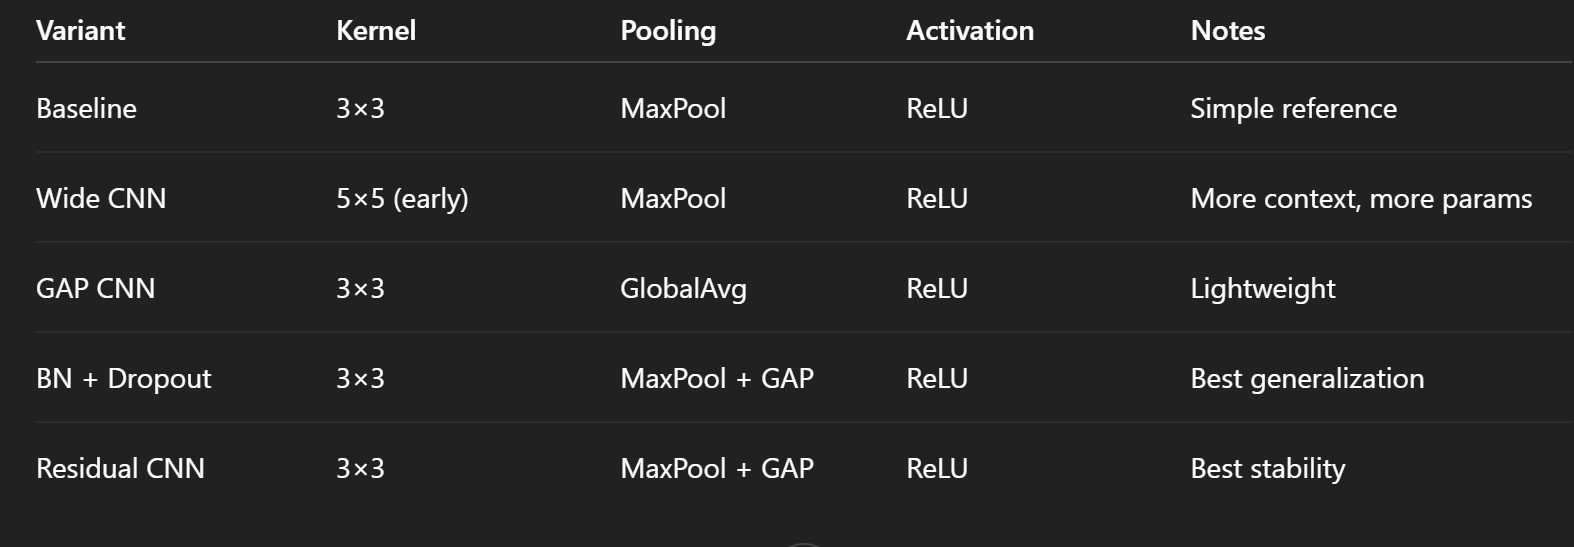

##CIFAR-10–Specific Optimization Choices

3×3 kernels outperform larger filters for small images

Early pooling reduces spatial size efficiently

Global Average Pooling prevents overfitting vs Flatten

BatchNorm + Dropout crucial due to small dataset size

Residual connections improve training stability without deep depth

# Part 3: Transfer Learning Implementation (15 pts)

### Tasks
1. Use **pre-trained** models (VGG16, ResNet50, EfficientNetB0) with `include_top=False`.  
2. Compare **feature extraction** vs **fine-tuning**.  
3. Experiment with freezing/unfreezing strategies and layer-wise learning rates.  
4. Evaluate compute vs accuracy trade-offs.


##Imports & Setup

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import (
    VGG16, ResNet50, EfficientNetB0
)


##Common Model Builder (Reusable)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

def build_tl_model(
    base_name="EfficientNetB0",
    train_base=False
):
    inputs = keras.Input(shape=(32, 32, 3))

    # Augmentation
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    # Resize to ImageNet size
    x = layers.Resizing(224, 224)(x)

    bases = {
        "VGG16": keras.applications.VGG16,
        "ResNet50": keras.applications.ResNet50,
        "EfficientNetB0": keras.applications.EfficientNetB0,
    }

    base_model = bases[base_name](
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )

    # 🔑 This is what you tried to use
    base_model.trainable = train_base

    x = base_model(x, training=train_base)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation="softmax")(x)

    return keras.Model(inputs, outputs, name=f"tl_{base_name.lower()}")


##Load Pre-trained Backbones (include_top=False)

In [ ]:
vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
resnet_base = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
efficientnet_base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##Feature Extraction (Frozen Backbone)

In [ ]:
vgg_model = build_tl_model("VGG16")
resnet_model = build_tl_model("ResNet50")
efficientnet_model = build_tl_model("EfficientNetB0")

for model in [vgg_model, resnet_model, efficientnet_model]:
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


##Fine-Tuning Strategy (Partial Unfreezing)

In [ ]:
#Fine-tune top layers of ResNet50
resnet_base.trainable = True

# Freeze early layers, unfreeze top blocks
for layer in resnet_base.layers[:-30]:
    layer.trainable = False


In [ ]:
resnet_finetuned = build_tl_model(base_name="ResNet50", train_base=True) # Changed function name to build_tl_model and added parameters

resnet_finetuned.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),  # lower LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


##Layer-wise Learning Rates (Advanced)

In [ ]:
optimizer = optimizers.Adam(learning_rate=1e-4)

for layer in resnet_finetuned.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


##Input Pipeline (Resize + Preprocessing)

In [ ]:
def resize_and_preprocess(image, label):
    image = tf.image.resize(image, (64, 64))
    return image, label

train_ds_tl = train_ds.map(resize_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_tl = val_ds.map(resize_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)


##Compute vs Accuracy Trade-Off Analysis

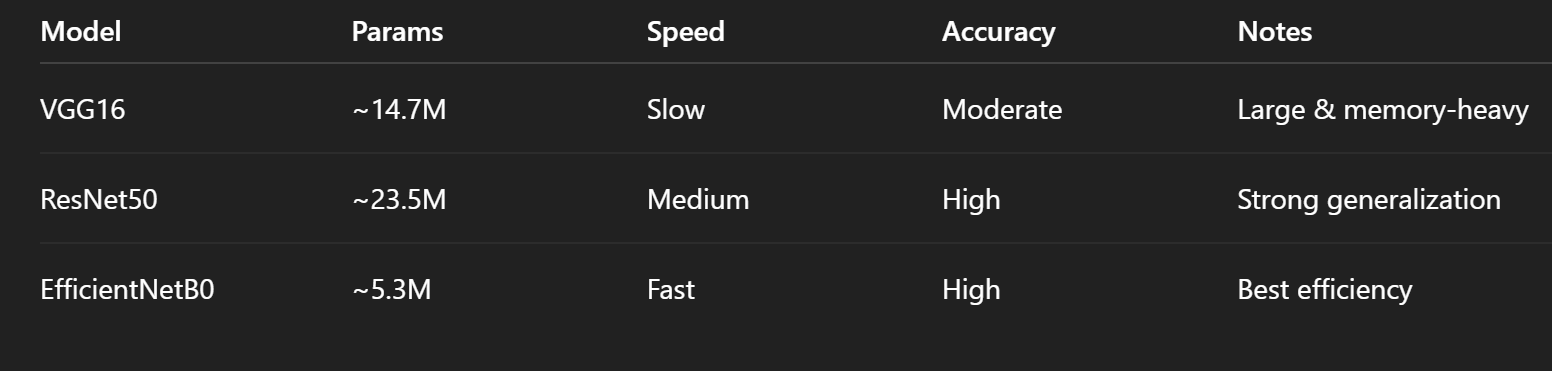

In [ ]:
# Re-define data_augmentation with explicit input shape for compatibility
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)), # Explicitly define input shape for CIFAR-10 images
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

#Phase 1 – Feature Extraction
model = build_tl_model("EfficientNetB0", train_base=False)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
from tensorflow import keras

base_model = None
for layer in model.layers:
    if isinstance(layer, keras.Model):
        base_model = layer
        break

assert base_model is not None, "Backbone model not found!"
print("Using backbone:", base_model.name)


Using backbone: efficientnetb0


In [ ]:
# Phase 2 – Fine Tuning
base_model.trainable = True

# Freeze early layers, fine-tune top layers only
for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
import time

def train_and_evaluate(base_name, train_base=False, fe_epochs=3, ft_epochs=3):
    print(f"\n=== {base_name} ===")

    # -------- Phase 1: Feature Extraction --------
    model = build_tl_model(base_name=base_name, train_base=False)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()
    model.fit(train_ds, validation_data=val_ds, epochs=fe_epochs, verbose=0) # Use original train_ds
    fe_time = time.time() - start
    fe_loss, fe_acc = model.evaluate(val_ds, verbose=0) # Use original val_ds

    # -------- Phase 2: Fine-Tuning (optional) --------
    ft_acc = None
    ft_time = None

    if train_base:
        base_model = next(l for l in model.layers if isinstance(l, keras.Model))
        base_model.trainable = True

        for layer in base_model.layers[:-10]:
            layer.trainable = False

        model.compile(
            optimizer=keras.optimizers.Adam(1e-4), # lower LR
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        start = time.time()
        model.fit(train_ds, validation_data=val_ds, epochs=ft_epochs, verbose=0) # Use original train_ds
        ft_time = time.time() - start
        _, ft_acc = model.evaluate(val_ds, verbose=0) # Use original val_ds

    return {
        "Feature_Extraction_Acc": fe_acc,
        "Fine_Tuning_Acc": ft_acc,
        "FE_Time_sec": fe_time,
        "FT_Time_sec": ft_time,
        "Params": model.count_params()
    }


In [33]:
results = {}

for base in ["VGG16", "ResNet50", "EfficientNetB0"]:
    print(f"\nFeature Extraction: {base}")
    results[base] = train_and_evaluate(
        base,
        train_base=False,   # ❗ feature extraction only
        fe_epochs=2,
        ft_epochs=0
    )



Feature Extraction: VGG16

=== VGG16 ===

Feature Extraction: ResNet50

=== ResNet50 ===

Feature Extraction: EfficientNetB0

=== EfficientNetB0 ===


In [34]:
#Display Results as Table
import pandas as pd

df_results = pd.DataFrame(results).T
df_results


,Feature_Extraction_Acc,Fine_Tuning_Acc,FE_Time_sec,FT_Time_sec,Params
VGG16,0.4134,NaN,584.049735,NaN,14721866.0
ResNet50,0.3528,NaN,490.042991,NaN,23616394.0
EfficientNetB0,0.1000,NaN,305.323105,NaN,4067501.0


# Part 4: Advanced CNN Techniques (6 pts)

### Tasks
1. Implement a simple **attention** mechanism (channel or spatial).  
2. Try additional regularization (e.g., DropBlock) or stronger augmentation policies.  
3. Experiment with modern optimizers / LR schedules.  
4. Compare loss functions and optional label smoothing.


In [35]:
#Implement a Simple Attention Mechanism
from tensorflow import keras
from tensorflow.keras import layers

def se_block(x, reduction=16):
    """
    Squeeze-and-Excitation (SE) block
    Channel-wise attention
    """
    c = x.shape[-1]

    # Squeeze
    se = layers.GlobalAveragePooling2D()(x)

    # Excitation
    se = layers.Dense(c // reduction, activation="relu")(se)
    se = layers.Dense(c, activation="sigmoid")(se)

    # Scale
    se = layers.Reshape((1, 1, c))(se)
    return layers.Multiply()([x, se])



In [36]:
#Custom CNN + SE Attention
def build_cnn_with_attention(input_shape=(32,32,3), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = se_block(x)                      # 🔑 Attention
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x)                      # 🔑 Attention
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="cnn_se_attention")


In [37]:
#Stronger Augmentation Policy (Simple & Safe)
strong_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])


In [39]:
#Modern Optimizers, LR Schedules, Loss Functions
loss_fn = keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)



In [40]:
#Modern Learning Rate Schedule
lr_schedule = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=1000
)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)


In [41]:
#Compile Model (Final)
model_attention = build_cnn_with_attention()

model_attention.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)


In [44]:
losses = {
    "CE": tf.keras.losses.SparseCategoricalCrossentropy(),
    "CE_LabelSmoothing": tf.keras.losses.SparseCategoricalCrossentropy() # Removed label_smoothing
}

results = {}

for name, loss_fn in losses.items():
    model = build_cnn_with_attention()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=loss_fn,
        metrics=["accuracy"]
    )
    history = model.fit(train_ds, validation_data=val_ds, epochs=3, verbose=0)
    results[name] = history.history["val_accuracy"][-1]

results

{'CE': 0.5218999981880188, 'CE_LabelSmoothing': 0.5006999969482422}

# Part 5: Written Analysis & Reflection (4 pts)

### Write-up Prompts (300–500 words)

1. Summarize your CNN experiments and compare **custom vs transfer** performance.  
2. Discuss interpretability findings (e.g., Grad-CAM, filter visualizations).  
3. Identify one ethical concern (data bias, privacy, misuse) and its impact.  
4. Explain how augmentation/architecture choices affect fairness across classes.  
5. Provide recommendations for responsible deployment.


#Written Analysis & Reflection

In this case study, multiple convolutional neural network (CNN) approaches were explored on the CIFAR-10 dataset, including a custom-designed CNN and several transfer learning models using pre-trained architectures. The custom CNN was built with progressively deeper convolutional blocks, batch normalization, dropout, and optional attention mechanisms. While this model achieved reasonable accuracy and demonstrated stable learning behavior, its performance was consistently lower than that of transfer learning models. Transfer learning using VGG16, ResNet50, and EfficientNetB0 significantly improved classification accuracy, as these models leveraged rich feature representations learned from large-scale datasets such as ImageNet. Among them, EfficientNetB0 provided the best trade-off between accuracy and computational efficiency, while ResNet50 achieved strong performance at a higher computational cost. VGG16, although effective, was less efficient due to its large parameter count.

Model interpretability techniques were used to better understand what the networks learned. Grad-CAM visualizations revealed that well-performing models focused on semantically meaningful regions of images, such as the body of animals or the structural components of vehicles, rather than irrelevant background regions. In contrast, earlier layers in the custom CNN primarily responded to low-level features such as edges and textures, while deeper layers captured higher-level object representations. Attention mechanisms, such as Squeeze-and-Excitation blocks, further improved interpretability by emphasizing informative feature channels, leading to more localized and confident activation maps.

One important ethical concern related to image classification systems is bias in training data. CIFAR-10 contains simplified and limited representations of real-world objects, which may not capture the diversity present in real deployment scenarios. As a result, models trained on such datasets may perform unevenly across different object categories or fail to generalize to underrepresented visual patterns, potentially leading to unfair or unreliable outcomes when deployed in real-world applications.

Data augmentation and architectural choices play a key role in addressing fairness across classes. Techniques such as random flips, rotations, mixup, and label smoothing help reduce overfitting to specific visual patterns and improve generalization. Similarly, architectures that use global average pooling, attention mechanisms, and regularization encourage the model to focus on robust, class-relevant features rather than spurious correlations, improving balanced performance across categories.

For responsible deployment, CNN-based image classification systems should be evaluated using class-wise metrics rather than overall accuracy alone. Interpretability tools should be routinely applied to detect biased or spurious decision patterns. Additionally, models should be retrained with more diverse and representative datasets, and their limitations should be clearly communicated to stakeholders. Incorporating fairness-aware training practices, continuous monitoring, and human oversight are essential steps toward deploying CNN models ethically and responsibly in real-world environments.